# COURSE: A deep understanding of deep learning
## SECTION: Style transfer
### LECTURE: Transfering the screaming bathtub
#### TEACHER: Mike X Cohen, sincxpress.com
##### COURSE URL: udemy.com/course/deeplearning_x/?couponCode=202401

In [1]:
### import libraries

# for DL modeling
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T

# to read an image from a url
from imageio import imread

# for number-crunching
import numpy as np

# for data visualization
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Import VGG19 and freeze all layers

In [2]:
# import the model
alexnet_weights = torchvision.models.AlexNet_Weights.DEFAULT
alexnet = torchvision.models.alexnet(weights=alexnet_weights)

# freeze all layers
for p in alexnet.parameters():
    p.requires_grad = False

# set to evaluation mode
alexnet.eval()

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /home/nuke/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100.0%


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [3]:
# send the network to the GPU if available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

alexnet.to(device)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

# Import two images

In [63]:
# NEW CODE
# Wikipedia their security protocols; use this cell instead of the next

import requests
from PIL import Image
from io import BytesIO

# import image for CONTENT
# url = 'https://upload.wikimedia.org/wikipedia/commons/6/61/De_nieuwe_vleugel_van_het_Stedelijk_Museum_Amsterdam.jpg'
url = 'https://upload.wikimedia.org/wikipedia/commons/7/75/Bee_hummingbird_%28Mellisuga_helenae%29_adult_male_non-breeding.jpg'
response = requests.get(url,headers={'User-Agent':'Mozilla/5.0 (compatible; ImageLoader/1.0)'})
img4content = np.array( Image.open(BytesIO(response.content)) ,dtype=np.uint8)

# import image for STYLE
# url = 'https://upload.wikimedia.org/wikipedia/commons/c/c5/Edvard_Munch%2C_1893%2C_The_Scream%2C_oil%2C_tempera_and_pastel_on_cardboard%2C_91_x_73_cm%2C_National_Gallery_of_Norway.jpg'
url = 'https://upload.wikimedia.org/wikipedia/commons/6/62/Brickwork_in_Flemish_Bond.jpg'
response = requests.get(url,headers={'User-Agent':'Mozilla/5.0 (compatible; ImageLoader/1.0)'})
img4style = np.array( Image.open(BytesIO(response.content)) ,dtype=np.uint8)

# initialize the target image and random numbers
img4target = np.random.randint(low=0,high=255,size=img4content.shape,dtype=np.uint8)

print(img4content.shape)
print(img4target.shape)
print(img4style.shape)

(1787, 2679, 3)
(1787, 2679, 3)
(2056, 3088, 3)


In [64]:
## These images are really large, which will make training take a long time.

# create the transforms
Ts = T.Compose([ T.ToTensor(),
                 T.Resize(256),
                 T.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
               ])

# apply them to the images ("unsqueeze" to make them a 4D tensor) and push to GPU
img4content = Ts( img4content ).unsqueeze(0).to(device)
img4style   = Ts( img4style   ).unsqueeze(0).to(device)
img4target  = Ts( img4target  ).unsqueeze(0).to(device)

print(img4content.shape)
print(img4target.shape)
print(img4style.shape)

torch.Size([1, 3, 256, 383])
torch.Size([1, 3, 256, 383])
torch.Size([1, 3, 256, 384])


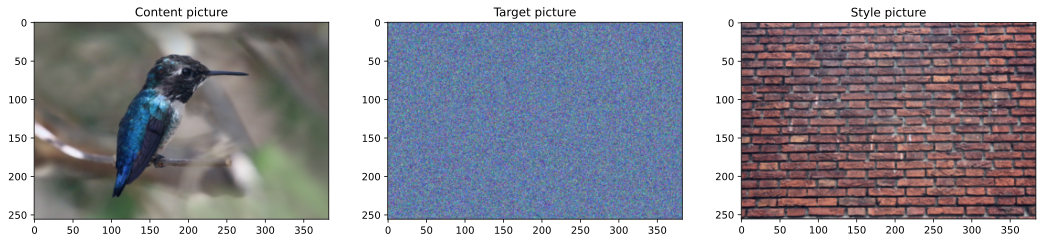

In [65]:
# Let's have a look at the "before" pics
fig,ax = plt.subplots(1,3,figsize=(18,6))

pic = img4content.cpu().squeeze().numpy().transpose((1,2,0))
pic = (pic-np.min(pic)) / (np.max(pic)-np.min(pic))
ax[0].imshow(pic)
ax[0].set_title('Content picture')

pic = img4target.cpu().squeeze().numpy().transpose((1,2,0))
pic = (pic-np.min(pic)) / (np.max(pic)-np.min(pic))
ax[1].imshow(pic)
ax[1].set_title('Target picture')

pic = img4style.cpu().squeeze().numpy().transpose((1,2,0))
pic = (pic-np.min(pic)) / (np.max(pic)-np.min(pic))
ax[2].imshow(pic)
ax[2].set_title('Style picture')

plt.show()

# Functions to extract image feature map activations

In [66]:
# A function that returns feature maps

def getFeatureMapActs(img,net):

  # initialize feature maps as a list
  featuremaps = []
  featurenames = []

  convLayerIdx = 0

  # loop through all layers in the "features" block
  for layernum in range(len(net.features)):

    # print out info from this layer
    # print(layernum,net.features[layernum])

    # process the image through this layer
    img = net.features[layernum](img)

    # store the image if it's a conv2d layer
    if 'Conv2d' in str(net.features[layernum]):
      featuremaps.append( img )
      featurenames.append( 'ConvLayer_' + str(convLayerIdx) )
      convLayerIdx += 1

  return featuremaps,featurenames

In [67]:
# A function that returns the Gram matrix of the feature activation map

def gram_matrix(M):

  # reshape to 2D
  _,chans,height,width = M.shape
  M = M.reshape(chans,height*width)

  # compute and return covariance matrix
  gram = torch.mm(M,M.t()) / (chans*height*width)
  return gram

In [68]:
# inspect the output of the function
featmaps,featnames = getFeatureMapActs(img4content,alexnet)

# print out some info
for i in range(len(featnames)):
  print('Feature map "%s" is size %s'%(featnames[i],(featmaps[i].shape)))

Feature map "ConvLayer_0" is size torch.Size([1, 64, 63, 95])
Feature map "ConvLayer_1" is size torch.Size([1, 192, 31, 47])
Feature map "ConvLayer_2" is size torch.Size([1, 384, 15, 23])
Feature map "ConvLayer_3" is size torch.Size([1, 256, 15, 23])
Feature map "ConvLayer_4" is size torch.Size([1, 256, 15, 23])


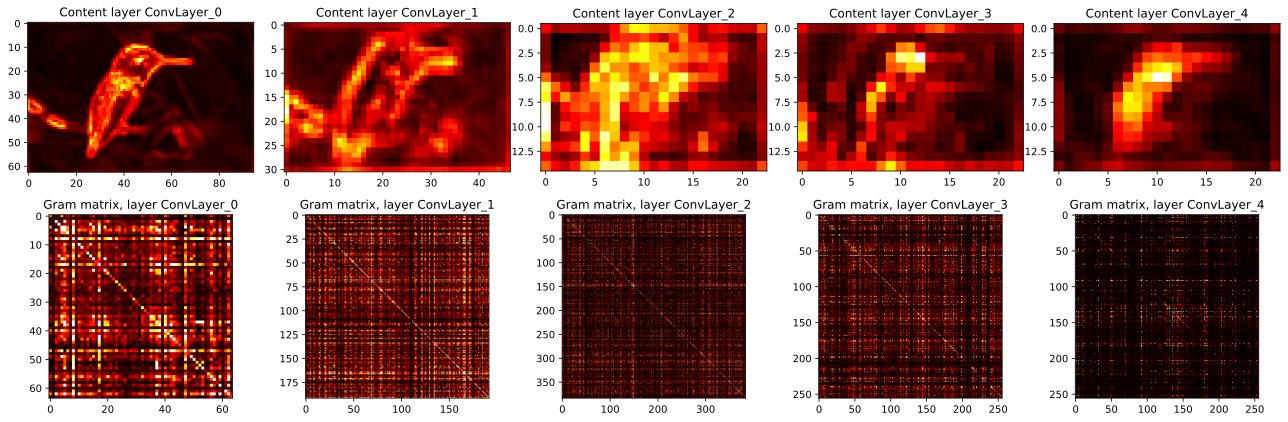

In [69]:
# let's see what the "content" image looks like
contentFeatureMaps,contentFeatureNames = getFeatureMapActs(img4content,alexnet)


fig,axs = plt.subplots(2,5,figsize=(18,6))
for i in range(5):

  # average over all feature maps from this layer, and normalize
  pic = np.mean( contentFeatureMaps[i].cpu().squeeze().numpy() ,axis=0)
  pic = (pic-np.min(pic)) / (np.max(pic)-np.min(pic))

  axs[0,i].imshow(pic,cmap='hot')
  axs[0,i].set_title('Content layer ' + str(contentFeatureNames[i]))


  ### now show the gram matrix
  pic = gram_matrix(contentFeatureMaps[i]).cpu().numpy()
  pic = (pic-np.min(pic)) / (np.max(pic)-np.min(pic))

  axs[1,i].imshow(pic,cmap='hot',vmax=.1)
  axs[1,i].set_title('Gram matrix, layer ' + str(contentFeatureNames[i]))

plt.tight_layout()
plt.show()

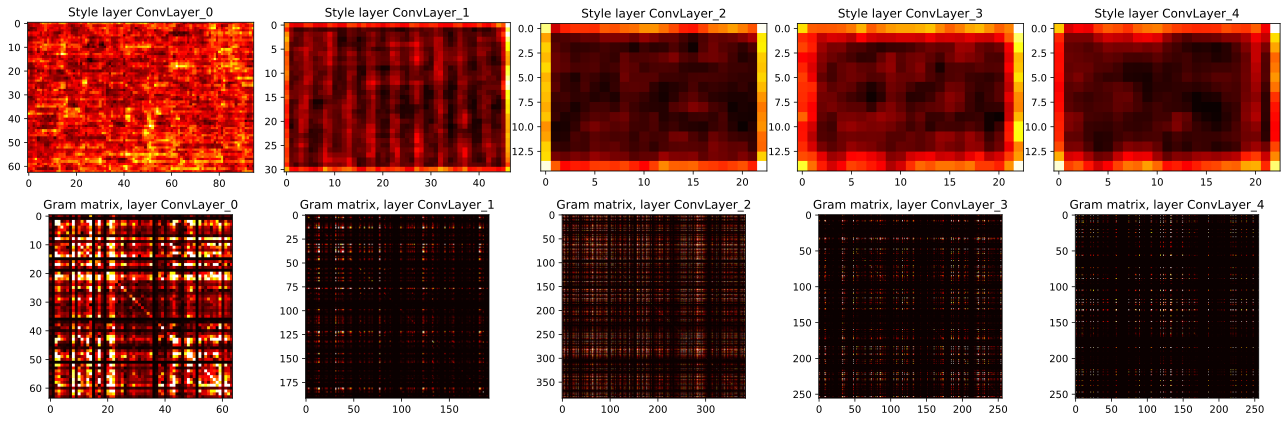

In [70]:

# repeat for the "style" image
styleFeatureMaps,styleFeatureNames = getFeatureMapActs(img4style,alexnet)


fig,axs = plt.subplots(2,5,figsize=(18,6))
for i in range(5):

  # average over all feature maps from this layer, and normalize
  pic = np.mean( styleFeatureMaps[i].cpu().squeeze().numpy() ,axis=0)
  pic = (pic-np.min(pic)) / (np.max(pic)-np.min(pic))

  axs[0,i].imshow(pic,cmap='hot')
  axs[0,i].set_title('Style layer ' + str(styleFeatureNames[i]))


  ### now show the gram matrix
  pic = gram_matrix(styleFeatureMaps[i]).cpu().numpy()
  pic = (pic-np.min(pic)) / (np.max(pic)-np.min(pic))

  axs[1,i].imshow(pic,cmap='hot',vmax=.1)
  axs[1,i].set_title('Gram matrix, layer ' + str(styleFeatureNames[i]))

plt.tight_layout()
plt.show()

# Now for the transfer

In [138]:
# which layers to use
layers4content = [ 'ConvLayer_0','ConvLayer_1' ]
layers4style   = [ 'ConvLayer_0','ConvLayer_1','ConvLayer_2','ConvLayer_3','ConvLayer_4' ]
weights4style  = [      1       ,     .2     ,     .001   ,     .001   ,     .001    ]

In [144]:
# make a copy of the target image and push to GPU
target = img4target.clone()
target.requires_grad = True
target = target.to(device)
styleScaling = 1e5

# number of epochs to train
numepochs = 1500

# optimizer for backprop
optimizer = torch.optim.RMSprop([target],lr=.001)


loss_matrix = np.zeros((numepochs,2))
img4target_over_epochs = np.zeros((numepochs, img4target.shape[0], img4target.shape[1], img4target.shape[2], img4target.shape[3]))

for epochi in range(numepochs):

  # extract the target feature maps
  targetFeatureMaps,targetFeatureNames = getFeatureMapActs(target,alexnet)


  # initialize the individual loss components
  styleLoss = 0
  contentLoss = 0

  # loop over layers
  for layeri in range(len(targetFeatureNames)):


    # compute the content loss
    if targetFeatureNames[layeri] in layers4content:
      contentLoss += torch.mean( (targetFeatureMaps[layeri]-contentFeatureMaps[layeri])**2 )


    # compute the style loss
    if targetFeatureNames[layeri] in layers4style:

      # Gram matrices
      Gtarget = gram_matrix(targetFeatureMaps[layeri])
      Gstyle  = gram_matrix(styleFeatureMaps[layeri])

      # compute their loss (de-weighted with increasing depth)
      styleLoss += torch.mean( (Gtarget-Gstyle)**2 ) * weights4style[layers4style.index(targetFeatureNames[layeri])]


  # combined loss
  combiloss = styleScaling*styleLoss + contentLoss
  loss_matrix[epochi,0] = styleLoss.item()
  loss_matrix[epochi,1] = contentLoss.item()
  
  img4target_over_epochs[epochi,:] = target.clone().detach().cpu().numpy()

  # finally ready for backprop!
  optimizer.zero_grad()
  combiloss.backward()
  optimizer.step()


# Let's have a looksie!

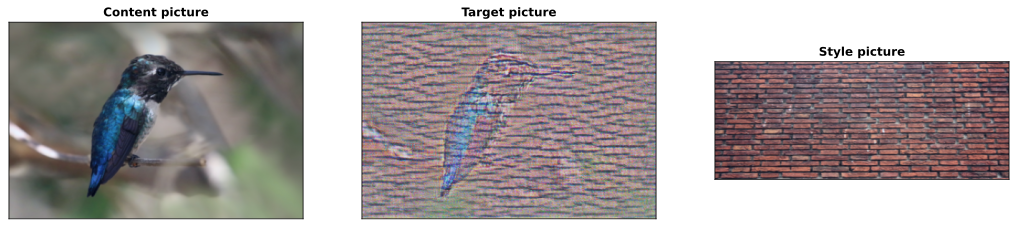

In [145]:
# the "after" pic
fig,ax = plt.subplots(1,3,figsize=(18,11))

pic = img4content.cpu().squeeze().numpy().transpose((1,2,0))
pic = (pic-np.min(pic)) / (np.max(pic)-np.min(pic))
ax[0].imshow(pic)
ax[0].set_title('Content picture',fontweight='bold')
ax[0].set_xticks([])
ax[0].set_yticks([])

pic = torch.sigmoid(target).cpu().detach().squeeze().numpy().transpose((1,2,0))
ax[1].imshow(pic)
ax[1].set_title('Target picture',fontweight='bold')
ax[1].set_xticks([])
ax[1].set_yticks([])

pic = img4style.cpu().squeeze().numpy().transpose((1,2,0))
pic = (pic-np.min(pic)) / (np.max(pic)-np.min(pic))
ax[2].imshow(pic,aspect=.6)
ax[2].set_title('Style picture',fontweight='bold')
ax[2].set_xticks([])
ax[2].set_yticks([])

plt.show()

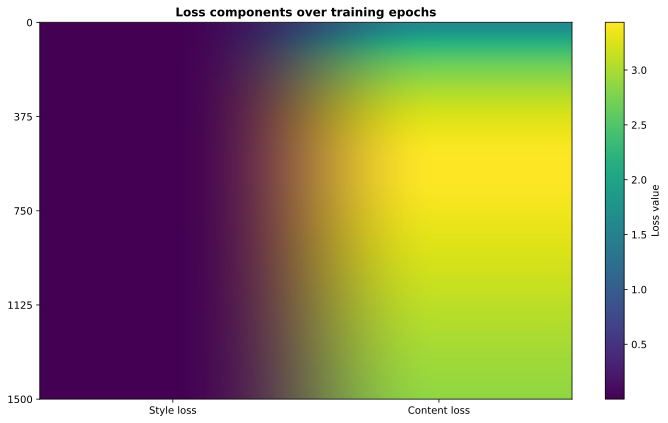

In [146]:
# 1) The minimization loss has two components (style and content). Modify the code to store these two components in a
#    Nx2 matrix (for N training epochs). Then plot them. This will help you understand and adjust the styleScaling gain
#    factor.

fig = plt.figure(figsize=(10,6))

plt.imshow(loss_matrix,aspect='auto')
plt.colorbar(label='Loss value')
plt.yticks( np.linspace(0,numepochs,5,dtype=int) )
plt.xticks( [0,1], ['Style loss','Content loss'] )
plt.title('Loss components over training epochs',fontweight='bold')
plt.tight_layout()
plt.show()

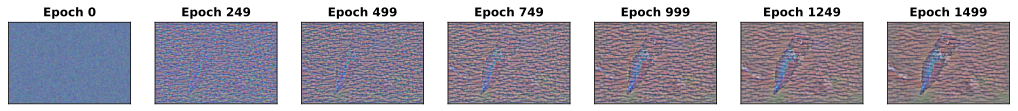

In [147]:
# 3) It's pretty neat to see the target image evolve over time. Modify the code to save the target image every, e.g.,
#    100 epochs. Then you can make a series of images showing how the noise transforms into a lovely picture.

num_plots = 7
fig,axs = plt.subplots(1,num_plots,figsize=(18,6))

for idx in range(num_plots):
    epoch_to_show = int( idx * (numepochs-1) / (num_plots-1) )

    pic = img4target_over_epochs[epoch_to_show,:,:,:].squeeze().transpose((1,2,0))
    pic = (pic-np.min(pic)) / (np.max(pic)-np.min(pic))

    axs[idx].imshow(pic)
    axs[idx].set_title('Epoch %d'%(epoch_to_show),fontweight='bold')
    axs[idx].set_xticks([])
    axs[idx].set_yticks([])

# Additional explorations

In [148]:
# 1) The minimization loss has two components (style and content). Modify the code to store these two components in a
#    Nx2 matrix (for N training epochs). Then plot them. This will help you understand and adjust the styleScaling gain
#    factor.
#
# 2) Change the layers for minimizing losses to content and style images. Do you notice an effect of minimizing the
#    earlier vs. later layers? How about more vs. fewer layers?
#
# 3) It's pretty neat to see the target image evolve over time. Modify the code to save the target image every, e.g.,
#    100 epochs. Then you can make a series of images showing how the noise transforms into a lovely picture.
#
# 4) The target picture was initialized as random noise. But it doesn't need to be. It can be initialized to anything
#    else. Try the following target initializations: (1) the content picture; (2) the style picture; (3) a completely
#    different picture (e.g., a picture of you or a cat or the Taj Mahal).
#